Episode 0 completed
Episode 10000 completed
Episode 20000 completed
Episode 30000 completed
Episode 40000 completed
Episode 50000 completed
Episode 60000 completed
Episode 70000 completed
Episode 80000 completed
Episode 90000 completed


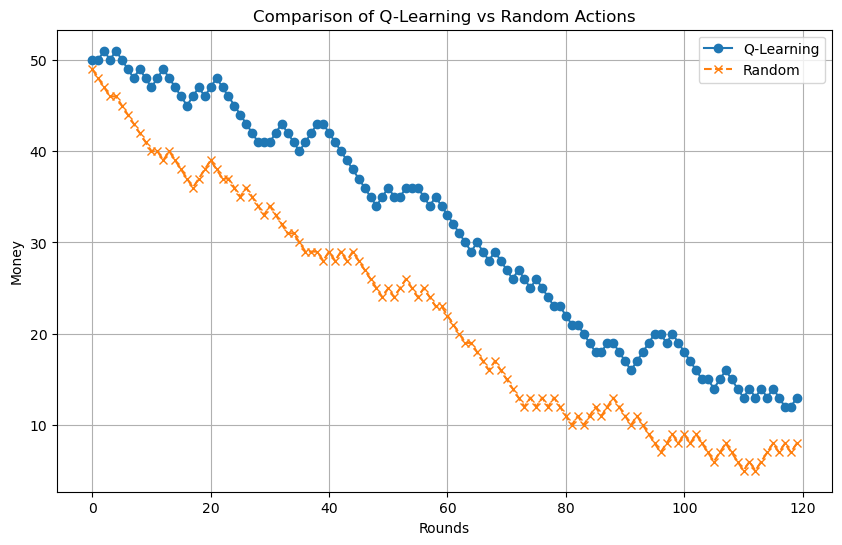

In [8]:
import numpy as np
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt


class BlackjackQLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.95, epsilon=1.0, epsilon_decay=0.99999, min_epsilon=0.01):
        self.q_values = defaultdict(lambda: np.zeros(2))
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
        return action

    def update(self, state, action, reward, next_state, done):
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_values[next_state])
        self.q_values[state][action] += self.lr * (target_q - current_q)


class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5):
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Tuple(
            (gym.spaces.Discrete(32), gym.spaces.Discrete(11), gym.spaces.Discrete(2))
        )
        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.money = 50
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action)
        if action:
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        self.money += reward
        return self._get_obs(), reward, terminated, self.money

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], self.usable_ace(self.player))

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        return self.new_round()

    def new_round(self):
        if len(self.deck) < 10:  # Reshuffle if the deck is nearly empty
            self.deck = self.original_deck.copy()
        self.dealer = self.draw_hand()
        self.player = self.draw_hand()
        return self._get_obs()

    def draw_card(self):
        if len(self.deck) == 0:
            self.deck = self.original_deck.copy()  # Reshuffle the deck
        card = self.deck.pop(np.random.randint(len(self.deck)))
        return card

    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]


def train_agent(env, agent, num_episodes):
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state)
            next_state, reward, done, _ = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
        if episode % 10000 == 0:
            print(f"Episode {episode} completed")


def simulate_q_learning(env, agent, num_rounds=120):
    q_learning_money = []
    for _ in range(num_rounds):
        state = env.new_round()
        done = False
        while not done:
            action = agent.get_action(state)
            state, reward, done, money = env.step(action)
        q_learning_money.append(env.money)
    return q_learning_money


def simulate_random(env, num_rounds=120):
    random_money = []
    for _ in range(num_rounds):
        state = env.new_round()
        done = False
        while not done:
            action = env.action_space.sample()
            state, reward, done, money = env.step(action)
        random_money.append(env.money)
    return random_money


# Initialize environment and agent
env = BlackjackEnv()
agent = BlackjackQLearningAgent()

# Train the Q-Learning agent
train_agent(env, agent, num_episodes=100000)

# Simulate both agents
q_learning_money = simulate_q_learning(env, agent, num_rounds=120)
env.reset()
random_money = simulate_random(env, num_rounds=120)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(range(len(q_learning_money)), q_learning_money, label='Q-Learning', linestyle='-', marker='o')
plt.plot(range(len(random_money)), random_money, label='Random', linestyle='--', marker='x')
plt.title('Comparison of Q-Learning vs Random Actions')
plt.xlabel('Rounds')
plt.ylabel('Money')
plt.legend()
plt.grid()
plt.show()


Episode 0 completed
Episode 10000 completed
Episode 20000 completed
Episode 30000 completed
Episode 40000 completed
Episode 50000 completed
Episode 60000 completed
Episode 70000 completed
Episode 80000 completed
Episode 90000 completed


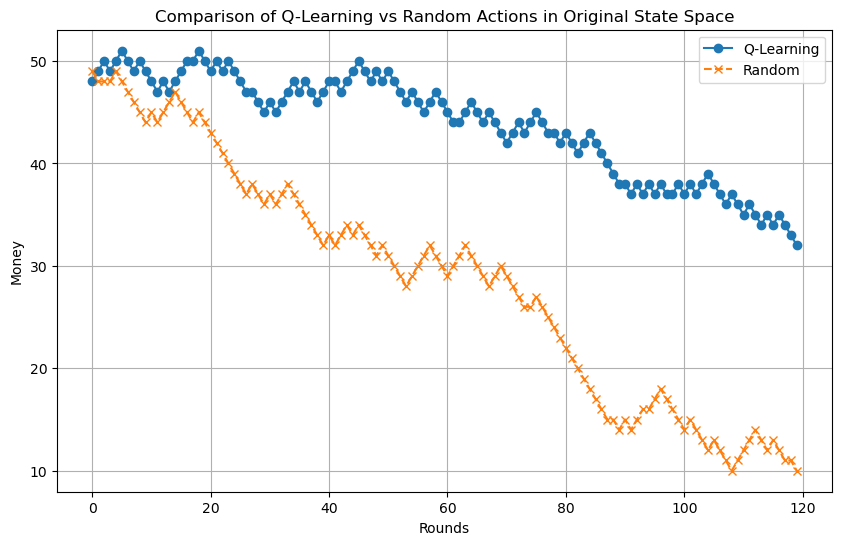

In [9]:
import numpy as np
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt


class BlackjackQLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.95, epsilon=1.0, epsilon_decay=0.99999, min_epsilon=0.01):
        self.q_values = defaultdict(lambda: np.zeros(2))
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
        return action

    def update(self, state, action, reward, next_state, done):
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_values[next_state])
        self.q_values[state][action] += self.lr * (target_q - current_q)


class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5):
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Tuple(
            (gym.spaces.Discrete(32), gym.spaces.Discrete(11), gym.spaces.Discrete(2))
        )
        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.money = 50
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action)
        if action:
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        self.money += reward
        return self._get_obs(), reward, terminated, self.money

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], self.usable_ace(self.player))

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        return self.new_round()

    def new_round(self):
        if len(self.deck) < 10:  # Reshuffle if the deck is nearly empty
            self.deck = self.original_deck.copy()
        self.dealer = self.draw_hand()
        self.player = self.draw_hand()
        return self._get_obs()

    def draw_card(self):
        if len(self.deck) == 0:
            self.deck = self.original_deck.copy()  # Reshuffle the deck
        card = self.deck.pop(np.random.randint(len(self.deck)))
        return card

    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]


def train_agent(env, agent, num_episodes):
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state)
            next_state, reward, done, _ = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
        if episode % 10000 == 0:
            print(f"Episode {episode} completed")


def simulate_q_learning(env, agent, num_rounds=120):
    q_learning_money = []
    for _ in range(num_rounds):
        state = env.new_round()
        done = False
        while not done:
            action = agent.get_action(state)
            state, reward, done, money = env.step(action)
        q_learning_money.append(env.money)
    return q_learning_money


def simulate_random(env, num_rounds=120):
    random_money = []
    for _ in range(num_rounds):
        state = env.new_round()
        done = False
        while not done:
            action = env.action_space.sample()
            state, reward, done, money = env.step(action)
        random_money.append(env.money)
    return random_money


# Initialize environment and agent
env = BlackjackEnv()
agent = BlackjackQLearningAgent()

# Train the Q-Learning agent
train_agent(env, agent, num_episodes=100000)

# Simulate both agents
q_learning_money = simulate_q_learning(env, agent, num_rounds=120)
env.reset()
random_money = simulate_random(env, num_rounds=120)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(range(len(q_learning_money)), q_learning_money, label='Q-Learning', linestyle='-', marker='o')
plt.plot(range(len(random_money)), random_money, label='Random', linestyle='--', marker='x')
plt.title('Comparison of Q-Learning vs Random Actions in Original State Space')
plt.xlabel('Rounds')
plt.ylabel('Money')
plt.legend()
plt.grid()
plt.show()
